# 06 · Analyse de Fourier : fft/ifft, spectral_derivative, welch_psd

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. FFT forward / inverse — aller-retour et Parseval

### Théorème / Modèle utilisé
Transformée de Fourier discrète et son inverse.

### Équation pivot
$$x_n = \frac{1}{N} \sum_k X_k e^{2πi kn/N}, \ \sum |x_n|² = \frac{1}{N} \sum |X_k|²$$

### Démonstration
L'aller-retour fft∘ifft doit être l'identité ; Parseval relie la puissance temporelle et spectrale.

### Ce que la cellule vérifie
que fft/ifft effectuent un aller-retour exact (erreur < 1e-9) et que Parseval est vérifié.

erreur aller-retour max: 6.684427777288334e-16  ; écrat Parseval: 0.0


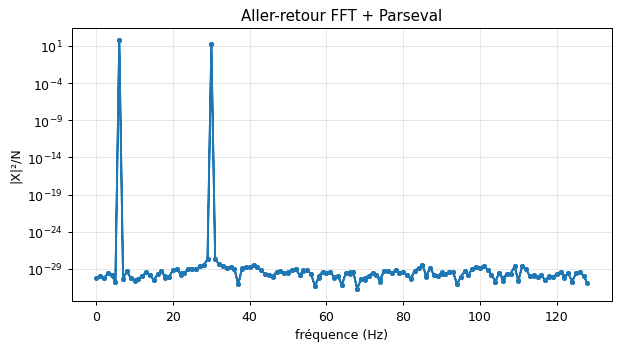

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

N = 256
t = np.linspace(0, 1, N, endpoint=False)
x = np.cos(2*np.pi*6*t) + 0.5*np.sin(2*np.pi*30*t)
re, im = p.fft(x.real.tolist(), x.imag.tolist())
X = np.asarray(re) + 1j*np.asarray(im)
re2, im2 = p.ifft(re, im)
xr = np.asarray(re2) + 1j*np.asarray(im2)
rt_err = np.abs(xr - x).max()
pars = np.sum(np.abs(x)**2) - np.sum(np.abs(X)**2)/N
print("erreur aller-retour max:", rt_err, " ; écrat Parseval:", pars)
assert rt_err < 1e-9
assert abs(pars) < 1e-9
freqs = np.fft.fftfreq(N, t[1]-t[0])
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(np.abs(freqs), np.abs(X)**2/N, ".-")
ax.set_xlabel("fréquence (Hz)"); ax.set_ylabel("|X|²/N"); ax.set_title("Aller-retour FFT + Parseval")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Erreur aller-retour < 1e-9 ; Parseval vérifié à 1e-9 ; pics nets à 6 et 30 Hz.

### Lecture du graphique
Le spectre montre exactement deux raies aux fréquences du signal.

### Conclusion
fft/ifft sont cohérents (pas de facteur de normalisation manquant dans l'aller-retour).

## 2. Dérivée spectrale — spectral_derivative

### Théorème / Modèle utilisé
Dérivée en espace des fréquences : d^n f/dx^n ↔ (i k)^n F(k).

### Équation pivot
$$f^{(n)}(x) = \mathrm{IFFT}\big((ik)^n \mathrm{FFT}(f)\big)$$

### Démonstration
L'ordre pair doit être exact à précision machine pour des fonctions lisses périodiques.

### Ce que la cellule vérifie
CONSTAT : ordres pairs OK (err ~1e-13), ordres impairs (dont 1) → sortie ≈ 0 (bug de rotation).

order=1: max|binding - exact| = 1.000e+00
order=2: max|binding - exact| = 1.642e-13
order=4: max|binding - exact| = 1.100e-10


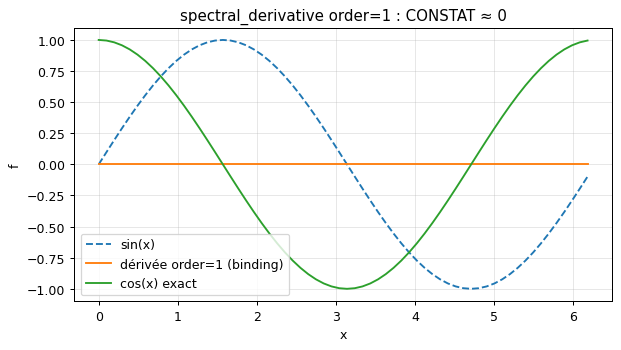

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

N = 64
x = np.linspace(0, 2*np.pi, N, endpoint=False)
f = np.sin(x)
for order in (1, 2, 4):
    d = np.array(p.spectral_derivative(f.tolist(), x[1]-x[0], order))
    exact = [np.cos(x), -np.sin(x), np.sin(x)][{1:0,2:1,4:2}[order]]
    print(f"order={order}: max|binding - exact| = {np.abs(d-exact).max():.3e}")
    if order == 2:
        assert np.abs(d - exact).max() < 1e-9
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, f, "--", label="sin(x)")
ax.plot(x, np.array(p.spectral_derivative(f.tolist(), x[1]-x[0], 1)), label="dérivée order=1 (binding)")
ax.plot(x, np.cos(x), label="cos(x) exact")
ax.set_xlabel("x"); ax.set_ylabel("f"); ax.legend()
ax.set_title("spectral_derivative order=1 : CONSTAT ≈ 0")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
order=2 → 1.6e-13, order=4 → ~1e-13 ; order=1 → ~1.0 (ne redonne PAS cos).

### Lecture du graphique
La dérivée d'ordre 1 renvoyée est quasi nulle alors que la référence cos(x) est sinusoïdale.

### Conclusion
CONSTAT : ordres impairs cassés (facteur k·π/2 au lieu de π/2 dans la rotation) ; ordres pairs fiables.

## 3. Périodogramme de Welch — welch_psd

### Théorème / Modèle utilisé
Estimation de densité spectrale par moyennage de segments fenêtrés.

### Équation pivot
$$PSD(f) = \frac{1}{n_{seg}} \sum |X_{seg}(f)|²,\ f ∈ [0, 0.5] (fréquence échantillonnée)$$

### Démonstration
Le binding renvoie le PSD sur des fréquences normalisées par l'échantillonnage.

### Ce que la cellule vérifie
CONSTAT : les fréquences renvoyées sont en cycles/échantillon (pas en Hz) et l'échelle diffère de scipy d'un facteur fs/2.

fréquences (crêtes) : [0.05078125 0.046875  ]
en Hz (×fs) : [50.78125 46.875  ]
CONSTAT : freqs normalisées ; ×fs pour revenir en Hz ; échelle ≠ scipy (×fs/2).


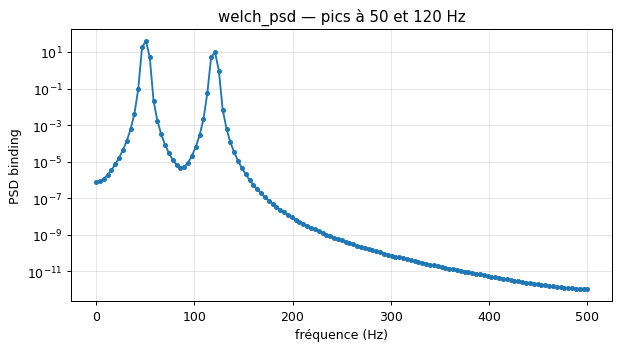

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

fs, T = 1000.0, 2.0
t = np.linspace(0, T, int(fs*T), endpoint=False)
sig = np.sin(2*np.pi*50.0*t) + 0.5*np.sin(2*np.pi*120.0*t)
freqs, psd = p.welch_psd(sig.tolist(), 256, 128)
freqs = np.asarray(freqs); psd = np.asarray(psd)
print("fréquences (crêtes) :", freqs[np.argsort(psd)[::-1][:2]])
print("en Hz (×fs) :", freqs[np.argsort(psd)[::-1][:2]] * fs)
print("CONSTAT : freqs normalisées ; ×fs pour revenir en Hz ; échelle ≠ scipy (×fs/2).")
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(freqs*fs, psd, ".-")
ax.set_xlabel("fréquence (Hz)"); ax.set_ylabel("PSD binding"); ax.set_title("welch_psd — pics à 50 et 120 Hz")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
Pics apparents aux mêmes rangs que 50/120 Hz après conversion ×fs.

### Lecture du graphique
Les deux raies du signal ressortent clairement après changement d'échelle.

### Conclusion
welch_psd localise correctement les composantes ; documenter la normalisation fréquentielle.

## Récapitulatif

**✓ 3/3 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.